# Охват рекламы в Яндекс Лавке


**Автор:** Артемьев Никита Константинович  
**Группа:** БПМ-244 

## 1. Бизнес-контекст

Рекламная команда планирует продавать рекламные места в приложении до 
конца 2026 года. Поэтому, чтобы предлагать места рекламодателям, команда должна 
понимать потенциальный охват каждого размещения (прогнозирование выручки и
эффективности рекламного места).

## 2. Исследовательский вопрос

Какой среднедневной охват может обеспечивать каждое из 5 рекламных мест в октябре, ноябре и декабре при условии показа всем пользователям без ограничений таргентинга?

## 3. Методология

В предоставленных данных нет признака просмотра баннера, поэтому будем предполагать, что вероятность P(пользователь увидит рекламу на определенном месте) = P(увидеть элемент интерфейса, который этот баннер замещает или рядом с которым он стоит), также большое внимание уделим анализу поведению пользователей: как часто они открывают приложение, посещают ленту и поиск, а также насколько глубоко просматривают ленту.

1) Рассчитаем поведение пользователей в сентябре:
    - рассчитаем DAU за сентябрь (file: `navigation_events.csv`),
    - охват баннеров в ленте: посчитаем количество уникальных пользователей в день для каждой посещенной карточки в ленте(`feed`) (file: `product_impressions.csv`),
    - охват баннера в поиске: посчитаем количество уникальных пользователей, посещающих поиск, в день (file: `navigation_events.csv`).

2) Расчет долей охвата:
    найдем `reach_rate = (уникальные пользователи места)/(общий DAU)` для каждого места в сентябре за 28 дней

3) Прогнозирование сентябрь-декабрь:
    Для каждого месяца рассчитаем среднедневной охват (file: `dau_forecast.csv`)
    `avg_dau_plan = (прогнозный DAU месяца) * (mean_reach_rate)`

## 4. Подготовка данных и реализация расчётов

### 4.1. Загрузка и знакомство с данными

| Таблица | Содержание |
|---|---|
| `dau_forecast.csv` | Средний DAU по месяцам: план на весь 2026 год и факт за январь–август. С сентября факт отсутствует. План октября–декабря — предоставленный командой прогноз активности для расчётов. |
| `navigation_events.csv` | Открытия приложения и посещения ленты, поиска и каталога за 1–28 сентября. Для каждого события указаны пользователь, время и тип события. |
| `product_impressions.csv` | Показы товарных карточек за 1–28 сентября с указанием пользователя, времени, раздела и позиции. Просмотр означает появление карточки на экране и не требует нажатия. |

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
dau_df = pd.read_csv('dau_forecast.csv')
navigation_df = pd.read_csv('navigation_events.csv')
impressions_df = pd.read_csv('product_impressions.csv')

In [66]:
display(dau_df.info())
display(dau_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   month           12 non-null     object
 1   avg_dau_plan    12 non-null     object
 2   avg_dau_actual  12 non-null     object
dtypes: object(3)
memory usage: 420.0+ bytes


None

,month,avg_dau_plan,avg_dau_actual
0,2026-01,"820,00","811,35"
1,2026-02,"840,00","853,18"
2,2026-03,"875,00","864,52"
3,2026-04,"900,00","913,70"
4,2026-05,"930,00","921,16"


In [67]:
display(navigation_df.info())
display(navigation_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91302 entries, 0 to 91301
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     91302 non-null  object
 1   timestamp   91302 non-null  object
 2   event_type  91302 non-null  object
 3   section     54161 non-null  object
dtypes: object(4)
memory usage: 2.8+ MB


None

,user_id,timestamp,event_type,section
0,u02703,01.09.2026 07:00:19,app_open,NaN
1,u04000,01.09.2026 07:00:19,app_open,NaN
2,u04000,01.09.2026 07:00:22,section_open,feed
3,u02703,01.09.2026 07:00:29,section_open,search
4,u02703,01.09.2026 07:00:50,section_open,search


In [68]:
display(impressions_df.info())  
display(impressions_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455882 entries, 0 to 455881
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     455882 non-null  object
 1   timestamp   455882 non-null  object
 2   section     455882 non-null  object
 3   product_id  455882 non-null  object
 4   row_number  455882 non-null  object
 5   column      455882 non-null  object
dtypes: object(6)
memory usage: 20.9+ MB


None

,user_id,timestamp,section,product_id,row_number,column
0,u04000,2026-09-01 07:00:24,feed,p0775,"1,0",left
1,u04000,2026-09-01 07:00:24,feed,p0842,"1,0",right
2,u04000,2026-09-01 07:00:28,feed,p1782,"2,0",left
3,u04000,2026-09-01 07:00:28,feed,p1788,"2,0",right
4,u02703,2026-09-01 07:00:31,search,p0723,"1,0",left


In [69]:
print("Описательная статистика dau_df:")
display(dau_df.describe(include='all'))
print("Описательная статистика navigation_df:")
display(navigation_df.describe(include='all'))
print("Описательная статистика impressions_df:")
display(impressions_df.describe(include='all'))

Описательная статистика dau_df:


,month,avg_dau_plan,avg_dau_actual
count,12,12,12
unique,12,12,9
top,2026-01,"820,00",—
freq,1,1,4


Описательная статистика navigation_df:


,user_id,timestamp,event_type,section
count,91302,91302,91302,54161
unique,4095,82960,2,9
top,u01250,12.09.2026 09:57:28,section_open,feed
freq,99,5,54161,29499


Описательная статистика impressions_df:


,user_id,timestamp,section,product_id,row_number,column
count,455882,455882,455882,455882,455882,455882
unique,4071,193448,9,1800,24,2
top,u03354,2026-09-16 09:03:48,feed,p1082,"1,0",left
freq,781,14,316055,315,98866,231328


В `dau_df` прогноз храниться в столбце `avg_dau_plan`, реальные же данные в `avg_dau_actual`(содержит пропуски за сентябрь-октябрь 2026). В `navigation_df` содержится лог событий пользователей. Самая объемная таблица `impression_df` содержит показы карточек. Столбец `row_number` показывает позицию в ленте.

### 4.2. Подготовка данных

In [70]:
# Преобразование дат в формат datetime и извлечение даты
navigation_df['timestamp'] = pd.to_datetime(navigation_df['timestamp'], 
                                format='%d.%m.%Y %H:%M:%S')
navigation_df['date'] = navigation_df['timestamp'].dt.date

impressions_df['timestamp'] = pd.to_datetime(impressions_df['timestamp'])
impressions_df['date'] = impressions_df['timestamp'].dt.date

dau_df['month'] = pd.to_datetime(dau_df['month']).dt.to_period('M')
print(dau_df.head())

     month avg_dau_plan avg_dau_actual
0  2026-01       820,00         811,35
1  2026-02       840,00         853,18
2  2026-03       875,00         864,52
3  2026-04       900,00         913,70
4  2026-05       930,00         921,16


In [71]:
# Преобразование текстовых данных в нижний регистр и удаление пробелов
for df in [navigation_df, impressions_df]:
    df['section'] = df['section'].astype('string').str.lower().str.strip()

navigation_df['event_type'] = navigation_df['event_type'].astype('string').str.lower().str.strip()

In [72]:
# Преобразование числовых данных
impressions_df['row_number'] = impressions_df['row_number'].astype('string').str.replace(',', '.', regex=False).astype(float)

def to_float(x):
    if pd.isna(x) or str(x).strip() == '—':
        return np.nan
    return float(str(x).replace('\xa0', '').replace(' ', '').replace(',', '.'))

dau_df['avg_dau_plan']   = dau_df['avg_dau_plan'].apply(to_float)
dau_df['avg_dau_actual'] = dau_df['avg_dau_actual'].apply(to_float)

In [73]:
print("Уникальные значения в navigation_df:")
for col in ['event_type', 'section']:
    print(f'Колонка: {col}')
    display(navigation_df[col].value_counts(dropna=False))

print("\nУникальные значения в impressions_df:")
for col in ['section', 'row_number', 'column']:
    print(f'Колонка: {col}')
    if col == 'row_number':
        display(impressions_df[col].value_counts().sort_index())
    else:
        display(impressions_df[col].value_counts(dropna=False))

Уникальные значения в navigation_df:
Колонка: event_type


event_type
section_open    54161
app_open        37141
Name: count, dtype: Int64

Колонка: section


section
<NA>       37141
feed       30764
search     13163
catalog    10234
Name: count, dtype: Int64


Уникальные значения в impressions_df:
Колонка: section


section
feed       329232
catalog     70046
search      56604
Name: count, dtype: Int64

Колонка: row_number


row_number
1.0     98866
2.0     74434
3.0     37559
4.0     44204
5.0     34980
6.0     17193
7.0     22908
8.0     18974
9.0     15950
10.0    13512
11.0    11696
12.0     5477
13.0     8970
14.0     7864
15.0     3639
16.0     6226
17.0     5488
18.0     4962
19.0     4520
20.0     4120
21.0     4168
22.0     3840
23.0     3520
24.0     2812
Name: count, dtype: int64

Колонка: column


column
left     231328
right    224554
Name: count, dtype: int64

In [74]:
# Диапазон дат
print('navigation:', navigation_df['date'].min(), ':', navigation_df['date'].max())
print('impressions:', impressions_df['date'].min(), ':', impressions_df['date'].max())

# Пропуски
print('navigation:', navigation_df.isna().sum())
print('impressions:', impressions_df.isna().sum())
print('dau:', dau_df.isna().sum())

# Дубликаты
print('navigation dups:', navigation_df.duplicated().sum())
print('impressions dups:', impressions_df.duplicated().sum())

# Уникальных пользователей
print('navigation users:', navigation_df['user_id'].nunique())
print('impressions users:', impressions_df['user_id'].nunique())

navigation: 2026-09-01 : 2026-09-28
impressions: 2026-09-01 : 2026-09-28
navigation: user_id           0
timestamp         0
event_type        0
section       37141
date              0
dtype: int64
impressions: user_id       0
timestamp     0
section       0
product_id    0
row_number    0
column        0
date          0
dtype: int64
dau: month             0
avg_dau_plan      0
avg_dau_actual    4
dtype: int64
navigation dups: 0
impressions dups: 0
navigation users: 4095
impressions users: 4071


1) `timestamp` в `navigation_events.csv` и `product_impressions.csv` приведён к `datetime`,
2) Категориальные поля `section` и `event_type` нормализованы,
3) Числовые строки `avg_dau_plan`, `avg_dau_actual`, `row_number` приведены к числовым типам,
4) В `section` для `app_open` остаются пропуски. Это ожидаемое поведение - у открытия приложения нет раздела.

### 4.3. Расчёты

Средний DAU за сентябрь: 1017
Минимум/максимум: 923/1150


<Axes: title={'center': 'DAU по дням'}, xlabel='Дата', ylabel='Количество уникальных пользователей'>

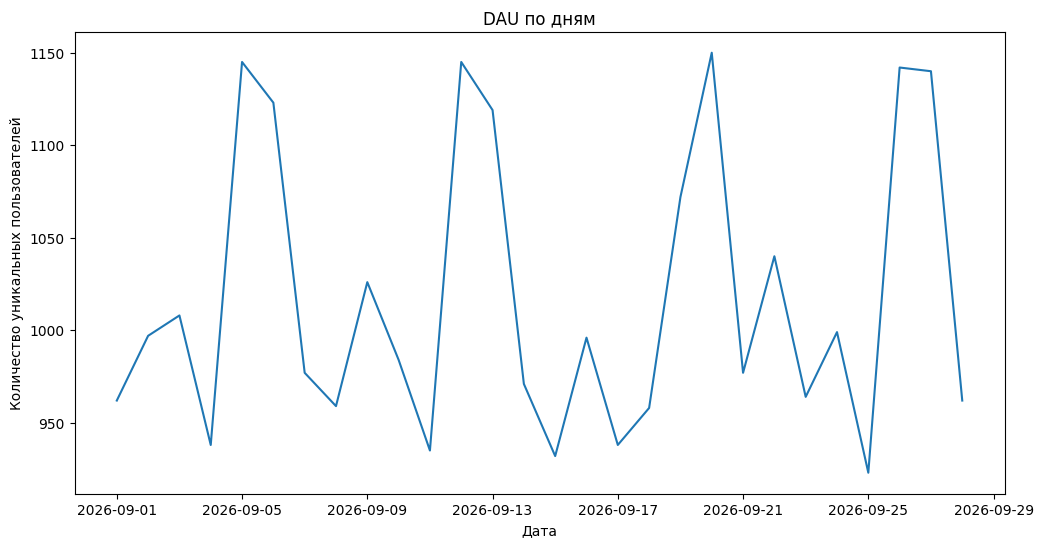

In [75]:
# Дневной DAU
dau_daily = navigation_df[navigation_df['event_type'] == 'app_open'].groupby('date')['user_id'].nunique().rename('dau')
print(f'Средний DAU за сентябрь: {dau_daily.mean():.0f}')
print(f'Минимум/максимум: {dau_daily.min()}/{dau_daily.max()}')
dau_daily.plot(title='DAU по дням', ylabel='Количество уникальных пользователей', xlabel='Дата', figsize=(12, 6))

На картинке мы видим из папки `image`, что 
| Баннер | row_number | column |
| --- | --- | --- |
| Сырная шпаргалка | 3 | right |
| Monterra | 6 | left |
| Манго с «Артфрут» | 12 | left |
| Идеи | 15 | right |

Поэтому рассчитаем дневной охват 4-х баннеров следующим образом

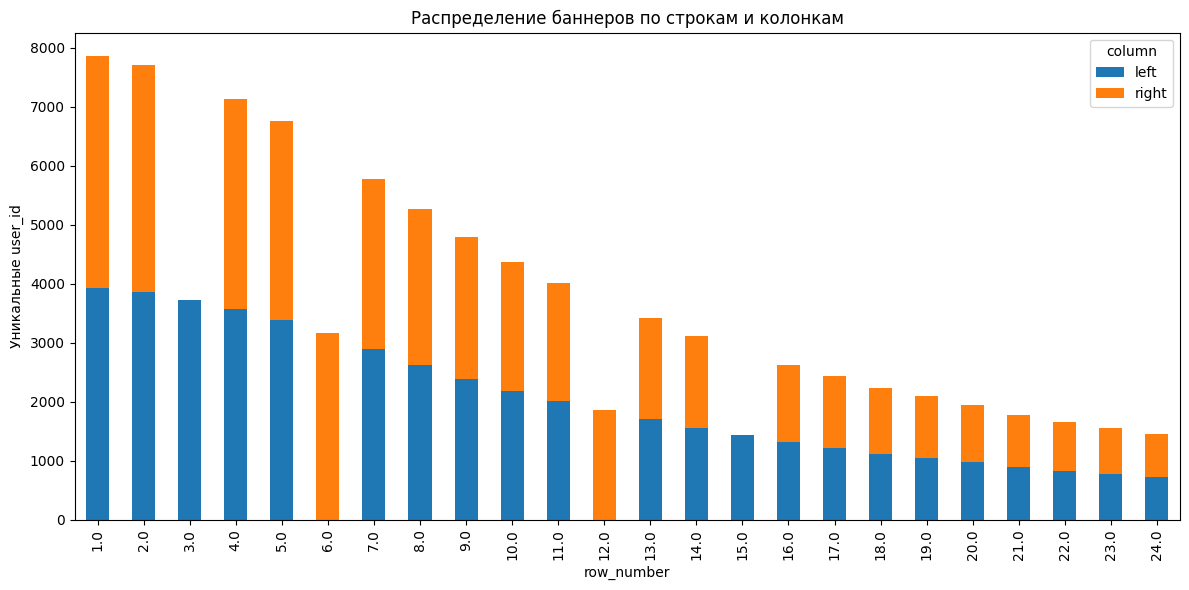

In [82]:
banner_data = impressions_df[impressions_df['section'] == 'feed'].groupby(['row_number', 'column'])['user_id'].nunique().unstack(fill_value=0)
banner_data.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('row_number')
plt.ylabel('Уникальные user_id')
plt.title('Распределение баннеров по строкам и колонкам')
plt.legend(title='column')
plt.tight_layout()
plt.show()

Баннеры занимают позиции, отмеченные на схеме ленты: (3, right), (6, left), (12, left), (15, right). В таблице product_impressions.csv эти позиции заняты рекламными баннерами, а не товарными карточками, поэтому прямых данных об охвате по ним нет. В качестве прокси используется охват товарной карточки в противоположной колонке того же ряда: в двухколоночной ленте пользователи, дошедшие до ряда, видят обе карточки.

Средний дневной охват баннеров в ленте за сентябрь:
feed_cheese_reach      499.0
feed_monterra_reach    313.0
feed_mango_reach       144.0
feed_ideas_reach       103.0
dtype: float64


<Axes: title={'center': 'Дневной охват баннеров в ленте'}, xlabel='Дата', ylabel='Количество уникальных пользователей'>

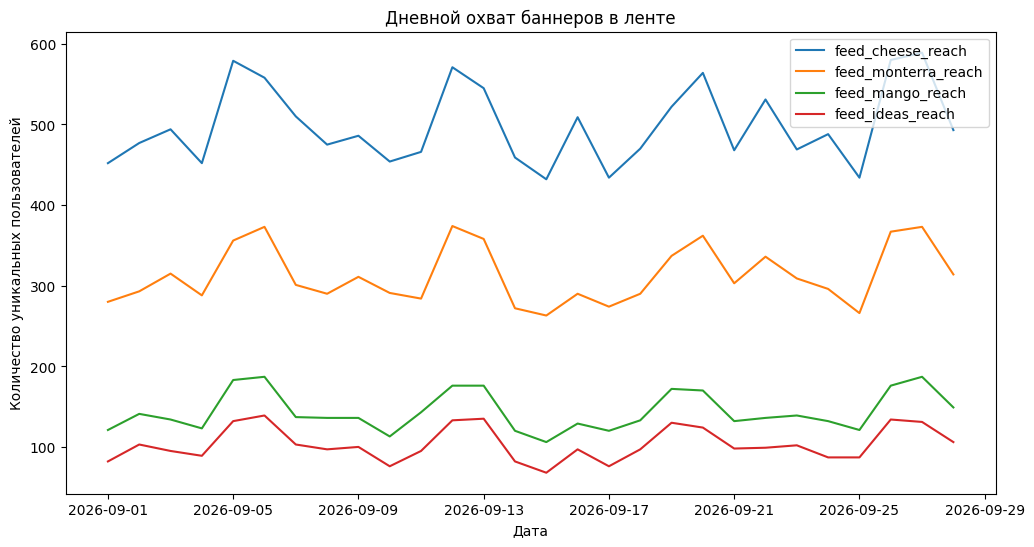

In [83]:
# Дневной охват 4-х баннеров в ленте
placement_banners = {'feed_cheese': (3, 'right'),
                     'feed_monterra': (6, 'left'),
                     'feed_mango': (12, 'left'),
                     'feed_ideas': (15, 'right')}

feed_impressions = impressions_df[impressions_df['section'] == 'feed'].copy()
reach_frames = {}
for banner, (row, column) in placement_banners.items():
    proxy_column = 'left' if column == 'right' else 'right'
    sub_df = feed_impressions[(feed_impressions['row_number'] == row) &
                               (feed_impressions['column'] == proxy_column)]
    reach_frames[banner] = sub_df.groupby('date')['user_id'].nunique().rename(banner + '_reach')

feed_reach_daily = pd.concat(reach_frames.values(), axis=1).fillna(0)
print(f'Средний дневной охват баннеров в ленте за сентябрь:\n{feed_reach_daily.mean().round(0)}')
feed_reach_daily.plot(title='Дневной охват баннеров в ленте', ylabel='Количество уникальных пользователей', xlabel='Дата', figsize=(12, 6))

Средний дневной охват баннера в поиске за сентябрь: 379


<Axes: title={'center': 'Дневной охват баннера в поиске'}, xlabel='Дата', ylabel='Количество уникальных пользователей'>

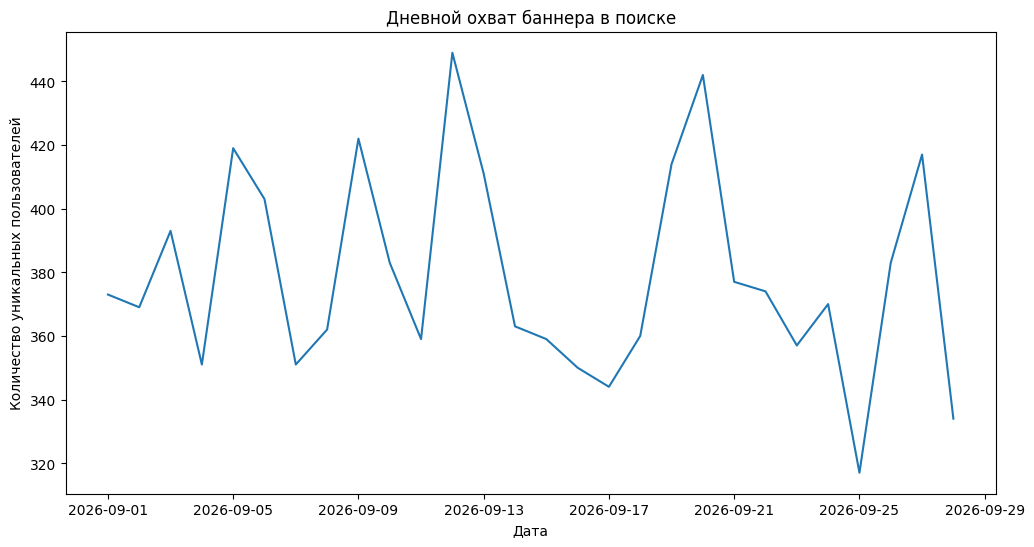

In [84]:
# Дневной охват баннера в поиске
search_reach_daily = navigation_df[(navigation_df['event_type'] == 'section_open') & (navigation_df['section'] == 'search')].groupby('date')['user_id'].nunique().rename('search_reach')
print(f'Средний дневной охват баннера в поиске за сентябрь: {search_reach_daily.mean():.0f}')
search_reach_daily.plot(title='Дневной охват баннера в поиске', ylabel='Количество уникальных пользователей', xlabel='Дата', figsize=(12, 6))

In [97]:
# Рассчет долей охвата баннеров в ленте и поиске
daily = pd.concat([dau_daily, search_reach_daily, feed_reach_daily], axis=1).fillna(0)

reach_columns = [c for c in daily.columns if c.endswith('_reach')]
for col in reach_columns:
    daily[col + '_share'] = daily[col] / daily['dau']

average_shares = daily[[c for c in daily.columns if c.endswith('_share')]].mean().round(4)
display(average_shares)

search_reach_share           0.3725
feed_cheese_reach_share      0.4896
feed_monterra_reach_share    0.3071
feed_mango_reach_share       0.1407
feed_ideas_reach_share       0.1010
dtype: float64

Доли охвата рассчитаны как отношение уникальных пользователей, увидевших место, к дневному DAU, усреднённое по 28 дням сентября. Для баннеров ленты в качестве охвата используется охват товарной карточки в противоположной колонке того же ряда — так как сама позиция занята рекламным баннером. Для баннера в поиске — уникальные пользователи, открывавшие раздел search. Все доли лежат в [0, 1]; охват в ленте монотонно убывает с глубиной ряда.

### 4.4. Результаты

Представьте оценку среднедневного охвата каждого выбранного места по месяцам — с октября по декабрь. Выберите понятный способ представления результатов и укажите единицы измерения.

In [ ]:
forecast = dau_df[dau_df['month'].dt.strftime('%Y-%m')
                  .isin(['2026-10', '2026-11', '2026-12'])
                  ][['month', 'avg_dau_plan']].copy()
forecast['month_label'] = forecast['month'].dt.strftime('%Y-%m')
forecast

,month,avg_dau_plan,month_label
9,2026-10,1080.0,2026-10
10,2026-11,1160.0,2026-11
11,2026-12,1320.0,2026-12


In [ ]:
place_map = {
    'feed_cheese_reach_share': 'Лента: Сырная шпаргалка',
    'feed_monterra_reach_share': 'Лента: Monterra',
    'feed_mango_reach_share': 'Лента: Манго',
    'feed_ideas_reach_share': 'Лента: Идеи',
    'search_reach_share': 'Поиск: большой баннер',
}
result = forecast[['month_label', 'avg_dau_plan']].copy()
for sc, name in place_map.items():
    result[name] = (result['avg_dau_plan'] * average_shares[sc]).round().astype(int)

result = result.rename(columns={'avg_dau_plan': 'DAU (план)'})
result

,month_label,DAU (план),Лента: Сырная шпаргалка,Лента: Monterra,Лента: Манго,Лента: Идеи,Поиск: большой баннер
9,2026-10,1080.0,529,332,152,109,402
10,2026-11,1160.0,568,356,163,117,432
11,2026-12,1320.0,646,405,186,133,492


In [ ]:
result_long = result.melt(
    id_vars=['month_label', 'DAU (план)'],
    var_name='placement',
    value_name='avg_daily_reach'
).sort_values(['month_label', 'placement'])

pivot = result_long.pivot(
    index='placement',
    columns='month_label',
    values='avg_daily_reach'
)
pivot

month_label,2026-10,2026-11,2026-12
placement,,,
Лента: Monterra,332,356,405
Лента: Идеи,109,117,133
Лента: Манго,152,163,186
Лента: Сырная шпаргалка,529,568,646
Поиск: большой баннер,402,432,492


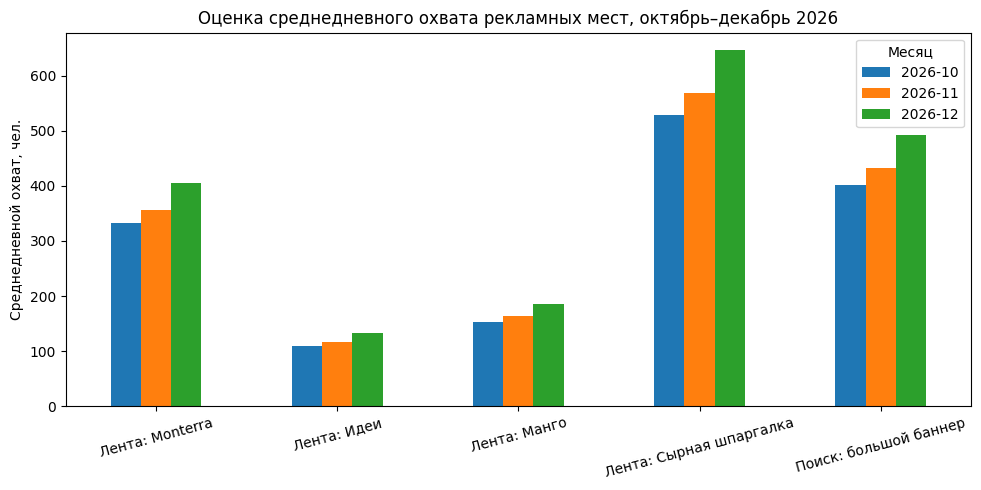

In [107]:
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=15)
ax.set_ylabel('Среднедневной охват, чел.')
ax.set_xlabel('')
ax.set_title('Оценка среднедневного охвата рекламных мест, октябрь–декабрь 2026')
ax.legend(title='Месяц')
plt.tight_layout()
plt.show()

Для каждого рекламного места среднедневной охват на месяц получен умножением прогнозного avg_dau_plan на среднюю долю охвата места за сентябрь. Единицы — уникальные пользователи в день. Оценка предполагает, что структура поведения пользователей (доля DAU, долистывающая до каждой позиции, и доля открывающих поиск) в октябре–декабре сохранится на уровне сентября.

## 5. Вывод

Ответьте на исследовательский вопрос, опираясь на результаты. Сформулируйте ответ так, чтобы рекламная команда могла использовать его при планировании.

*Ваш вывод.*

## 6. Ограничения

Что ограничивает применимость ваших оценок? Объясните, как это влияет на интерпретацию и использование результатов.

*Ваш текст.*